# Tema IS - Etapa 1

## Setup initial

In [66]:
import os
import numpy as np
import pandas as pd
import torch
import random
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix, accuracy_score
from tqdm import tqdm
from PIL import Image
import cv2
from sklearn.model_selection import KFold

Imaginile medicale CT au specific: contrast variabil, zgomot, artefacte.
Am definit cateva transformari custom pe care le testez mai tarziu pentru a vedea care imbunatatesc vizibilitatea hemoragiilor:

- **HistogramEq**: egalizare clasica de histogram - creste contrastul global, dar poate amplifica zgomotul
- **CLAHE**: egalizare adaptativa - imbunatateste contrastul local fara sa amplifice zgomotul excesiv. E mai buna decat HistEq pentru imagini medicale.
- **GaussianBlur**: reduce zgomotul prin blurring, dar poate pierde detalii fine (edge-uri)
- **SobelEdge**: detecteaza marginile in imagine - utila pentru a vedea contururi clare ale structurilor, dar pierde informatia de intensitate
- **ZscoreNormalize**: normalizeaza pe baza mediei si deviatiei standard - scala liniara, utila pentru a face valorile comparabile intre imagini

**Nota**: Voi testa vizual fiecare transformare pe cateva imagini random si voi alege pe cele mai relevante pentru augmentarea datelor de train. 

In [67]:
class HistogramEqTransform:
    def __call__(self, img):
        img_np = np.array(img)
        img_eq = cv2.equalizeHist(img_np)
        return Image.fromarray(img_eq)

class CLAHETransform:
    def __init__(self, clipLimit=2.0, tileGridSize=(8,8)):
        # clipLimit: cat de mult creste contrastul (valori mici = mai putin agresiv)
        # tileGridSize: marimea patch-urilor pe care se aplica adaptiv (mai mic = mai local)
        self.clahe = cv2.createCLAHE(clipLimit=clipLimit, tileGridSize=tileGridSize)
    def __call__(self, img):
        img_np = np.array(img)
        img_eq = self.clahe.apply(img_np)
        return Image.fromarray(img_eq)

class GaussianBlurTransform:
    def __init__(self, ksize=5, sigma=0):
        # ksize: marimea kernel-ului (mai mare = mai mult blur)
        # sigma: deviatia standard (0 = calculata automat)
        self.ksize = (ksize, ksize)
        self.sigma = sigma
    def __call__(self, img):
        img_np = np.array(img)
        blurred = cv2.GaussianBlur(img_np, self.ksize, self.sigma)
        return Image.fromarray(blurred)

class SobelEdgeTransform:
    def __call__(self, img):
        img_np = np.array(img)
        # calculez gradientul in x si y
        sobelx = cv2.Sobel(img_np, cv2.CV_64F, 1, 0, ksize=3)
        sobely = cv2.Sobel(img_np, cv2.CV_64F, 0, 1, ksize=3)
        # magnitudinea gradientului (cat de "tare" e marginea)
        sobel = np.hypot(sobelx, sobely)
        # scalare la [0, 255] pentru vizualizare
        if sobel.max() > 0:
            sobel = np.uint8(np.clip(sobel / sobel.max() * 255, 0, 255))
        else:
            sobel = np.zeros_like(img_np, dtype=np.uint8)
        return Image.fromarray(sobel)

class ZscoreNormalizeTransform:
    def __call__(self, img):
        img_np = np.array(img).astype(np.float32)
        mean = img_np.mean(); std = img_np.std() if img_np.std() > 0 else 1 # evita div by zero
        normed = (img_np - mean) / std # z-score
        # scalare la [0, 255] pentru vizualizare (doar pentru display, nu pentru training!)
        normed_disp = np.clip((normed - normed.min()) / (normed.max() - normed.min()) * 255, 0, 255).astype(np.uint8)
        return Image.fromarray(normed_disp)

Definesc 3 pipeline-uri diferite pentru train, validation/test si demo vizual. 

**De ce am ales augmentarile acestea?**

M-am documentat despre ce functioneaza bine pe imagini medicale CT (creier) si am evitat transformarile care pot denatura informatia clinica:

- **Horizontal flip** - Da, scanarile CT ale creierului sunt aproximativ simetrice anatomic, deci flip-ul e safe
- **Vertical flip** - NU, creierul nu e simetric vertical, deci nu aplic
- **Rotatie ±10°** - Da, mici rotatii simuleaza variatii de pozitionare a pacientului in scanner.  Peste ±15° deja denaturez prea mult
- **CLAHE (70% probabilitate)** - Da, e standard pentru CT-uri. Imbunatateste contrastul local si evidentiaza hemoragiile fara sa amplifice zgomotul excesiv. Nu aplic pe toate imaginile ca sa las si cateva "curate"
- **ColorJitter (brightness/contrast)** - Da, simuleaza variatii de calibrare intre scanere diferite. Dar nu exagerez (valori mici)
- **Crop/Zoom agresiv** - NU. Hemoragiile pot fi mici si la margini, deci nu vreau sa risc sa tai zone relevante
- **Elastic deformations** - NU (deocamdata). Sunt utile pentru segmentare, dar pot denatura prea mult forma hemoragiilor pentru clasificare

**Val/Test** - fara nicio augmentare (doar resize + normalize), ca sa evaluez pe date "adevarate" si sa compar corect cu train

**Demo** - doar resize, fara ToTensor/Normalize, ca sa pot vizualiza transformarile custom direct pe imagini PIL

In [68]:
MY_IMAGE_SIZE = (256, 256)
import torchvision.transforms as transforms
train_transform = transforms.Compose([
    transforms.Resize(MY_IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomApply([CLAHETransform()], p=0.7),
    transforms.ColorJitter(brightness=0.2, contrast=0.4),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
val_transform = transforms.Compose([
    transforms.Resize(MY_IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
demo_transform = transforms.Compose([transforms.Resize(MY_IMAGE_SIZE)])

In [69]:
import os

BASE_INPUT = "/kaggle/input/rsna-dataset"

BASE_DIR = os.path.join(BASE_INPUT, "rsna-intracranial-hemorrhage-detection-png")
TRAIN_IMAGES_DIR = os.path.join(BASE_DIR, "train_images")
TEST_IMAGES_DIR = os.path.join(BASE_DIR, "test_images")

# CSV-uri
CSV_TRAIN_PATH = os.path.join(BASE_INPUT, "subdataset_train.csv")
CSV_TEST_PATH = os.path.join(BASE_INPUT, "subdataset_test.csv")

# verificari
assert os.path.isdir(TRAIN_IMAGES_DIR), f"Lipseste {TRAIN_IMAGES_DIR}"
assert os.path.isdir(TEST_IMAGES_DIR), f"Lipseste {TEST_IMAGES_DIR}"
assert os.path.isfile(CSV_TRAIN_PATH), f"Lipseste {CSV_TRAIN_PATH}"
assert os.path.isfile(CSV_TEST_PATH), f"Lipseste {CSV_TEST_PATH}"

print("Datele au fost gasite cu succes")

Datele au fost gasite cu succes


In [70]:
# incarc CSV-urile in DataFrames (Pandas e eficient pentru tabele mari)
df_train = pd.read_csv(CSV_TRAIN_PATH)
df_test = pd.read_csv(CSV_TEST_PATH)

# verific structura datelor (primele 5 randuri)
print("Train:")
display(df_train.head())
print("Test:")
display(df_test.head())

Train:


,ID,Label
0,ID_ff7125125_epidural,0
1,ID_ff7125125_intraparenchymal,0
2,ID_ff7125125_intraventricular,0
3,ID_ff7125125_subarachnoid,1
4,ID_ff7125125_subdural,0


Test:


,ID,Label
0,ID_6c860ad30_epidural,0
1,ID_6c860ad30_intraparenchymal,0
2,ID_6c860ad30_intraventricular,0
3,ID_6c860ad30_subarachnoid,0
4,ID_6c860ad30_subdural,1


In [71]:
def process_df(df):
    # ID este format din ceva de genul <prefix>_<slice_id>_<subtype>
    # il spargem in coloane
    parts = df["ID"].str.split("_", expand=True)
    df["prefix"] = parts[0]
    df["slice_id"] = parts[1]
    df["subtype"] = parts[2]

    # pivotam pentru a obtine 1 rand/slice
    df_pivot = df.pivot_table(
        index="slice_id",
        columns="subtype",
        values="Label",
        fill_value=0
    ).reset_index()

    return df_pivot

In [72]:
train_clean = process_df(df_train)
test_clean  = process_df(df_test)

print("Train clean:")
display(train_clean.head())

print("Test clean:")
display(test_clean.head())

Train clean:


subtype,slice_id,any,epidural,intraparenchymal,intraventricular,subarachnoid,subdural
0,0007b61ef,0.0,0.0,0.0,0.0,0.0,0.0
1,000825230,0.0,0.0,0.0,0.0,0.0,0.0
2,000a050f3,1.0,0.0,0.0,0.0,1.0,1.0
3,000bd98e8,0.0,0.0,0.0,0.0,0.0,0.0
4,000d4a142,0.0,0.0,0.0,0.0,0.0,0.0


Test clean:


subtype,slice_id,any,epidural,intraparenchymal,intraventricular,subarachnoid,subdural
0,0002a38ad,1.0,0.0,0.0,0.0,1.0,1.0
1,000d66d9e,1.0,0.0,0.0,0.0,1.0,1.0
2,000fbb8e0,0.0,0.0,0.0,0.0,0.0,0.0
3,001c0458a,1.0,0.0,1.0,1.0,1.0,0.0
4,001d37aff,1.0,0.0,0.0,0.0,1.0,0.0


In [73]:
# verific daca toate slice_id-urile din CSV au imaginea corespunzatoare pe disk
def check_missing_images(df, images_dir):
    missing = []
    for slice_id in df["slice_id"]:
        img_name = f"ID_{slice_id}_frame0.png"
        path = os.path.join(images_dir, img_name)
        if not os.path.exists(path):
            missing.append(img_name)
    return missing

missing_train = check_missing_images(train_clean, TRAIN_IMAGES_DIR)
missing_test  = check_missing_images(test_clean, TEST_IMAGES_DIR)

print("Lipsesc in train:", len(missing_train))
print("Lipsesc in test:", len(missing_test))

Lipsesc in train: 0
Lipsesc in test: 0


## Cerinta 1: clasa personalizata in PyTorch

Definesc `RSNADataset` - clasa custom care mosteneste din `torch. utils.data.Dataset`.   
Imi trebuie asta pentru ca datasetul RSNA nu e in format standard: am CSV cu etichete si imagini separate pe disk.  
Clasa implementeaza cele 3 metode obligatorii: `__init__()` (initializare cu dataframe + path imagini), `__len__()` (numarul de sample-uri) si `__getitem__(idx)` (incarcare imagine + etichete la indexul dat).  
Imaginile sunt grayscale (CT-uri), etichetele sunt vectori de 6 valori (0/1) transformati in tensori float32 pentru loss-ul BCE. 

In [74]:
from PIL import Image
import os
import torch

class RSNADataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.data = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

        # coloanele labelurilor
        self.label_columns = ["epidural","intraparenchymal","intraventricular",
                              "subarachnoid","subdural","any"]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # luam randul idx din dataframe
        row = self.data.iloc[idx]

        # compun numele imaginii
        slice_id = row["slice_id"]
        img_path = os.path.join(self.image_dir, f"ID_{slice_id}_frame0.png")

        # incarc imaginea
        image = Image.open(img_path).convert("L")
        if self.transform:
            image = self.transform(image)

        # conversie SAFE a labelurilor
        labels = torch.tensor(
            row[self.label_columns].astype(float).to_numpy(),
            dtype=torch.float32
        )

        return image, labels

In [75]:
# test rapid: creez dataset si extrag primul sample
ds_basic = RSNADataset(train_clean, TRAIN_IMAGES_DIR, transform=val_transform)
img, lbl = ds_basic[0]  # extrag prima imagine + etichete
print(lbl)  # verific ca etichetele sunt tensor cu 6 valori (0/1)

tensor([0., 0., 0., 0., 0., 0.])


## Cerinta 2: split 80% train, 20% test

Impart dataframe-ul `train_clean` in train (80%) si validation (20%) folosind `train_test_split` din sklearn.  
Setez `random_state=42` pentru reproductibilitate si `shuffle=True` ca sa amestec randurile inainte de split. 

**De ce nu K-Fold?**  
K-Fold cross-validation e mai robust (antreneaza pe K configuratii diferite de train/val si medieaza rezultatele), dar e **mult mai costisitor** - inseamna sa antrenez modelul de K ori (de ex. 5 fold = 5 antrenari complete).  
Pentru baseline-ul de la etapa 1, am preferat sa experimentez rapid cu un singur split 80/20 si sa verific ca pipeline-ul functioneaza conform asteptarilor.  
Voi reveni cu K-Fold pentru a valida robustetea modelului si a obtine metrici mai fiabile in etapa urmatoare de tuning.

In [76]:
train_df, val_df = train_test_split(
    train_clean, # dataframe-ul procesat la cerinta 1
    test_size=0.2, # 20% pentru validare
    random_state=42, # pentru reproductibilitate
    shuffle=True # amestecam randurile inainte de split
)
# verificam dimensiunea
print(f"Train: {len(train_df)}, Validation: {len(val_df)}")

Train: 32282, Validation: 8071


In [77]:
# dataset pentru antrenare cu transformari augmentate
train_dataset = RSNADataset(train_df.reset_index(drop=True), TRAIN_IMAGES_DIR, transform=train_transform)

# dataset pentru validare (fara augmentare)
val_dataset = RSNADataset(val_df.reset_index(drop=True), TRAIN_IMAGES_DIR, transform=val_transform)

# dataset pentru test (fara augmentare)
test_dataset = RSNADataset(test_clean.reset_index(drop=True), TEST_IMAGES_DIR, transform=val_transform)

## Cerinta 3: vizualizarea distributiei claselor

Definesc o functie pentru a vizualiza distributia pozitivelor (numarul de imagini cu fiecare tip de hemoragie) pe train, validation si test.  

**Ce observ din grafice:**
- Exista un **dezechilibru major** intre clase - `any` (orice hemoragie) apare pe ~11,000+ imagini, in timp ce `epidural` apare pe doar ~2,500 imagini (de ~4-5x mai rar)
- Celelalte clase (intraparenchymal, subdural, etc.) au frecvente moderate (~3,500-4,500)
- Distributia e similara pe train si validation (bine, inseamna ca split-ul e echilibrat)
- Pe **test**, epidural e si mai rar (se vede diferenta clara) - asta inseamna ca modelul va avea dificultati sa o detecteze bine daca nu iau masuri

**Ce voi face pentru a rezolva dezechilibrul:**
- **pos_weight in BCE loss** - penalizez mai tare erorile pe clasele rare (modelul "invata" ca epidural conteaza mai mult)
- **WeightedRandomSampler** - supraesantionez imagini cu epidural in batch-uri (voi vedea mai des exemple rare in timpul antrenarii)
- **Threshold tuning pe validation** - voi ajusta pragul de decizie per clasa (nu las totul la 0.5 default)

Fara aceste tehnici, modelul ar ignora epidural si ar prezice mereu "0" (ca sa minimizeze loss-ul pe majoritatea). 

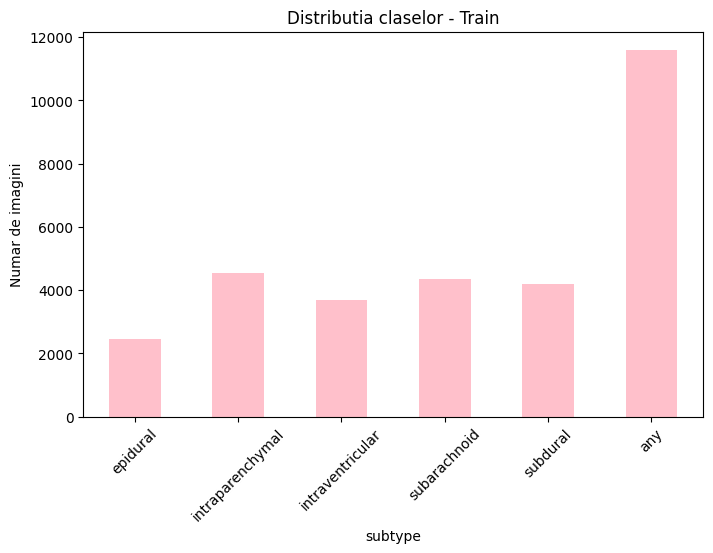

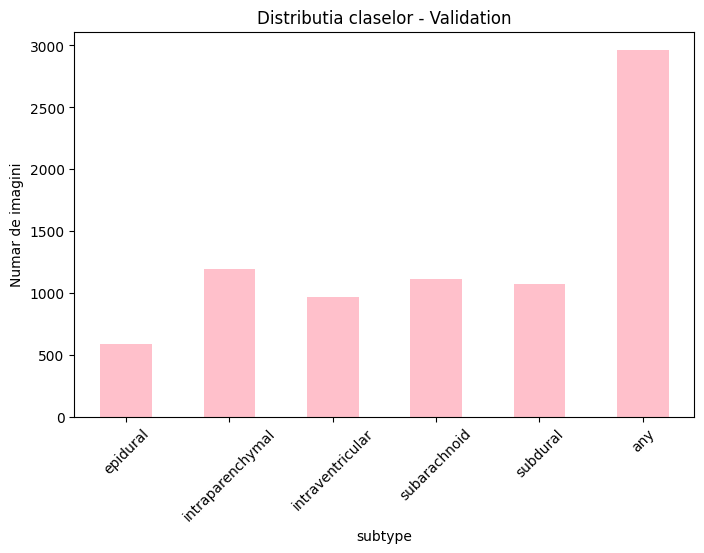

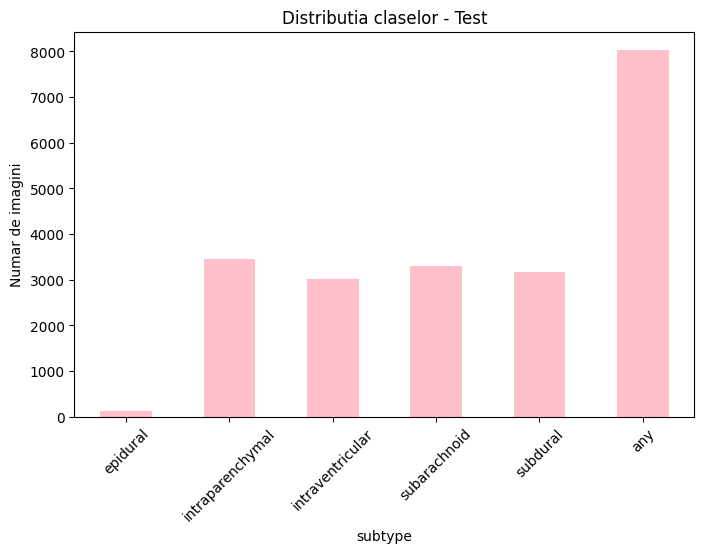

In [78]:
def plot_class_distribution(df, title="Distributia claselor"):
    # excludem slice_id
    class_cols = ["epidural", "intraparenchymal", "intraventricular", "subarachnoid", "subdural", "any"]

    counts = df[class_cols].sum()

    plt.figure(figsize=(8,5))
    counts.plot(kind='bar', color='pink')
    plt.title(title)
    plt.ylabel("Numar de imagini")
    plt.xticks(rotation=45)
    plt.show()

# vizualizare pentru train, validation si test
plot_class_distribution(train_df, "Distributia claselor - Train")
plot_class_distribution(val_df, "Distributia claselor - Validation")
plot_class_distribution(test_clean, "Distributia claselor - Test")

## Cerinta 4: analiza vizuala detaliata a imaginilor

Extrag si afisez cate 5 imagini din fiecare clasa pentru a observa direct caracteristicile vizuale ale fiecarui tip de hemoragie.   

**Ce caut:**
- Unde se localizeaza fiecare tip de hemoragie (epidural la margine, intraparenchymal in tesut, etc)
- Cat de variabile sunt imaginile din aceeasi clasa (marime, forma, contrast)
- Daca exista confuzii vizuale intre clase (epidural vs subdural arata similar, ambele la periferie)

**Observatii** (detaliate in raport):  
Epidural si subdural sunt greu de diferentiat vizual.   Intraparenchymal si intraventricular au localizari mai clare.  
Asta explica de ce modelul va avea dificultati pe anumite clase si de ce am nevoie de tehnici de balansare (pos_weight, sampler, threshold tuning). 

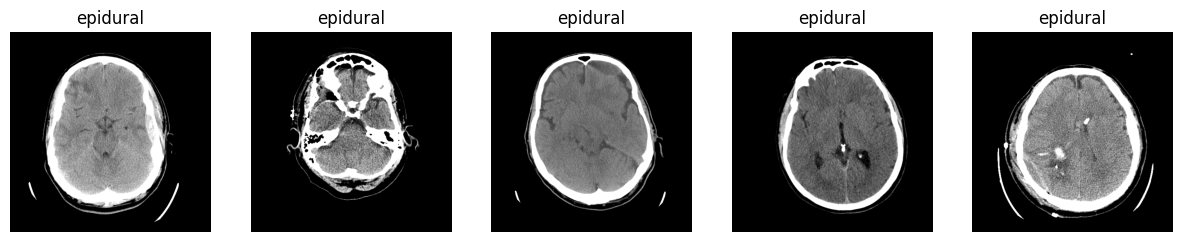

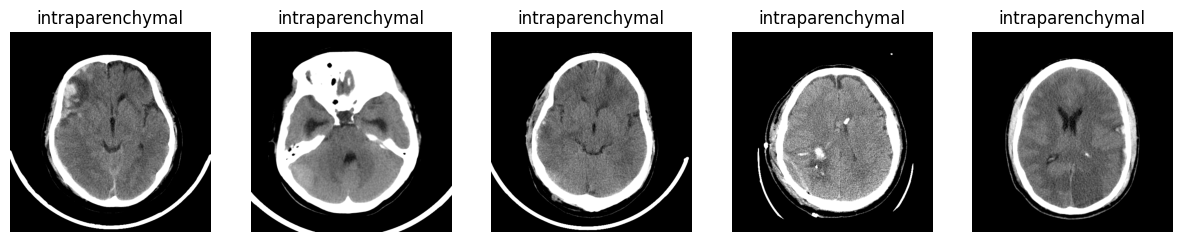

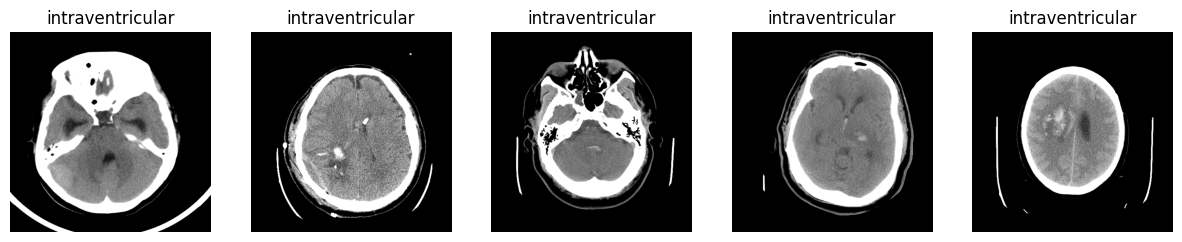

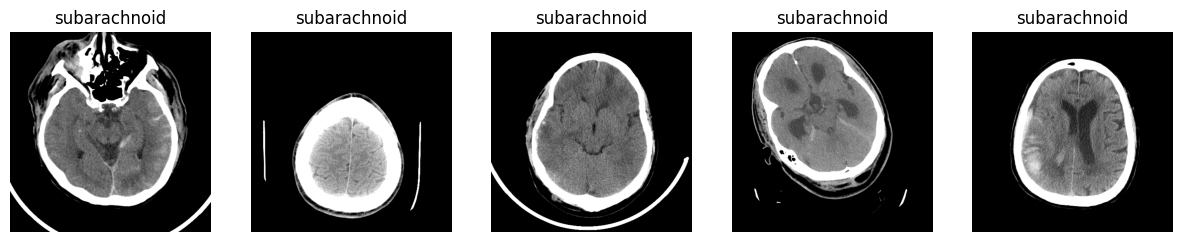

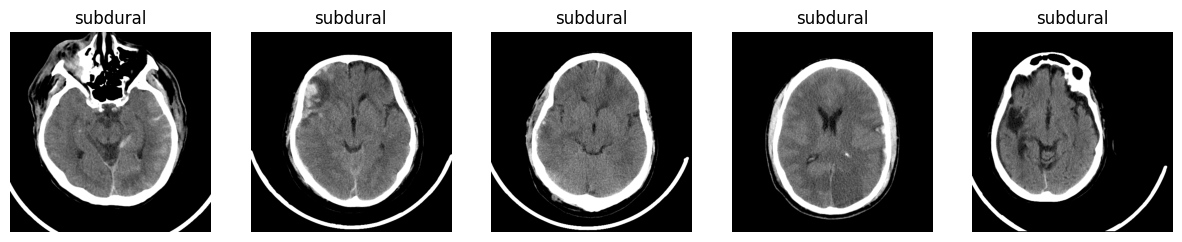

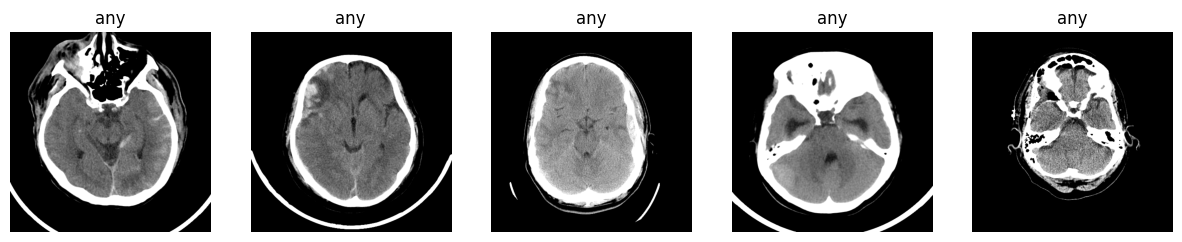

In [79]:
from PIL import Image
import os

# tipurile de hemoragii
classes = ['epidural', 'intraparenchymal', 'intraventricular', 'subarachnoid', 'subdural', 'any']
num_samples = 5  # cate imagini per clasa

for cls in classes:
    # extrag primele num_samples slice_id-uri cu clasa pozitiva
    slice_ids = train_clean[train_clean[cls] == 1]['slice_id']. tolist()[:num_samples]

    plt.figure(figsize=(15, 3))
    for i, sid in enumerate(slice_ids):
        img_path = os.path.join(TRAIN_IMAGES_DIR, f'ID_{sid}_frame0.png')
        img = Image.open(img_path)
        
        plt.subplot(1, num_samples, i+1)
        plt.imshow(img, cmap='gray')
        plt.axis('off')
        plt.title(cls)
    plt.show()

## Cerinta 5: verificarea consistentei datasetului

Verific daca toate imaginile din dataset au:
- **Acelasi numar de canale** (grayscale vs RGB) - important pentru compatibilitate cu modelul 
- **Dimensiuni uniforme** - daca sunt diferite, trebuie resize obligatoriu in pipeline
- **Range de pixeli consistent** - verific daca sunt [0, 255] sau altceva, ca sa aleg normalizarea corecta

Colectez statistici pentru fiecare imagine (height, width, channels, pixel_min, pixel_max) si apoi analizez distributia pentru a identifica inconsistente.  

**Solutii pentru uniformizare** (deja implementate in pipeline):
- **Canale diferite** → `.convert("L")` in `RSNADataset.__getitem__()` (forteaza grayscale)
- **Dimensiuni diferite** → `transforms.Resize(MY_IMAGE_SIZE)` in pipeline (resize la 256x256)
- **Range de pixeli** → `transforms.Normalize(mean=[0.5], std=[0.5])` (scalare la [-1,1])

In [80]:
import os
from PIL import Image
from tqdm.notebook import tqdm
import pandas as pd

image_info = []

# iterez prin toate imaginile din train
all_images = os.listdir(TRAIN_IMAGES_DIR)

for fname in tqdm(all_images, desc="Analiza imaginilor"):
    fpath = os.path.join(TRAIN_IMAGES_DIR, fname)

    try:
        img = Image.open(fpath)
        arr = np.array(img)

        # numar de canale (1 = grayscale, 3 = RGB)
        if arr.ndim == 2:
            channels = 1
        else:
            channels = arr.shape[2]

        # dimensiuni (height, width)
        h, w = arr.shape[:2]

        # range de pixeli (min, max)
        pixel_min = arr.min()
        pixel_max = arr.max()

        image_info.append([fname, h, w, channels, pixel_min, pixel_max])

    except Exception as e:
        # daca imaginea e corupta, salvez None-uri
        image_info.append([fname, None, None, None, None, None])

# salvez intr-un DataFrame pentru analiza
df_info = pd.DataFrame(image_info, columns=[
    "filename", "height", "width", "channels", "pixel_min", "pixel_max"
])

df_info.head()

Analiza imaginilor:   0%|          | 0/40353 [00:00<?, ?it/s]

,filename,height,width,channels,pixel_min,pixel_max
0,ID_ff0afaa64_frame0.png,512,512,1,0,255
1,ID_c86b6c961_frame0.png,512,512,1,0,255
2,ID_817d2de9e_frame0.png,512,512,1,0,255
3,ID_10a53afba_frame0.png,512,512,1,0,255
4,ID_c8808df88_frame0.png,512,512,1,0,255


In [81]:
print("Distributia numarului de canale:")
display(df_info["channels"].value_counts())

print("\nDistributia dimensiunilor unice:")
display(df_info.groupby(["height", "width"]).size())

print("\nStatistici pixel values:")
display(df_info[["pixel_min", "pixel_max"]].describe())

Distributia numarului de canale:


channels
1    40353
Name: count, dtype: int64


Distributia dimensiunilor unice:


height  width
408     374          2
430     404          4
464     464          3
512     512      40341
638     490          2
666     512          1
dtype: int64


Statistici pixel values:


,pixel_min,pixel_max
count,40353.000000,40353.000000
mean,0.014472,252.700072
std,0.611026,23.673097
min,0.000000,0.000000
25%,0.000000,255.000000
50%,0.000000,255.000000
75%,0.000000,255.000000
max,41.000000,255.000000


In [82]:
# sumarizare probleme identificate
issues = {}

# 1. valori unice pentru numar de canale
unique_channels = df_info["channels"].dropna(). unique()
issues["channels"] = unique_channels.tolist()

# 2. dimensiuni unice (height, width)
unique_sizes = df_info[["height", "width"]].dropna(). drop_duplicates()
issues["unique_sizes"] = unique_sizes.values.tolist()

# 3. range global de pixeli (min si max peste toate imaginile)
pixel_min_global = df_info["pixel_min"].min()
pixel_max_global = df_info["pixel_max"].max()
issues["pixel_min_global"] = pixel_min_global
issues["pixel_max_global"] = pixel_max_global

# afisez sumarul
issues

{'channels': [1],
 'unique_sizes': [[512, 512],
  [408, 374],
  [638, 490],
  [464, 464],
  [430, 404],
  [666, 512]],
 'pixel_min_global': 0,
 'pixel_max_global': 255}

In [83]:
# exemplu de verificare: shape si range dupa aplicarea pipeline-ului de transformari
img, lbl = ds_basic[5]  # extrag o imagine random din dataset
print("Imagine shape dupa transformari:", img.shape)  # asteptat: (1, 256, 256) pentru grayscale
print("Min/max dupa transformari:", img.min().item(), img.max().item())  # asteptat: [-1, 1] dupa Normalize(0.5, 0.5)

Imagine shape dupa transformari: torch.Size([1, 256, 256])
Min/max dupa transformari: -1.0 1.0


## Cerinta 6: operatii de preprocesare si normalizare

Aplic cele 5+ transformari custom (definite la inceput) pe 5 imagini random din train_dataset pentru a compara vizual impactul fiecarei tehnici. 

**Transformarile testate:**
1. **HistogramEq** - egalizare histogram clasica: creste contrastul global, dar amplifica zgomotul.   Utila pentru imagini cu contrast slab, dar agresiva. 
2. **CLAHE** - egalizare adaptativa locala: imbunatateste contrastul fara zgomot excesiv.  **Cea mai buna pentru CT-uri** (standard in imagistica medicala).
3. **GaussianBlur** - reduce zgomotul prin smoothing, dar pierde detalii fine (margini).  Utila pentru denoise, dar nu vreau sa pierd contururi de hemoragii.
4. **Sobel** - detecteaza marginile (edge detection): evidentiaza contururi, dar pierde informatia de intensitate.  Utila pentru analiza, nu pentru training.
5. **ZscoreNormalize** - normalizare statistica (mean=0, std=1): scala liniara, utila pentru comparabilitate intre imagini.  Nu schimba vizual mult, dar ajuta modelul. 

**Concluzie** (dupa vizualizare):  
Din analiza vizuala, **CLAHE** si eventual **ZscoreNormalize** sunt cele mai potrivite pentru augmentare. HistEq e prea agresiv, Gaussian pierde detalii, Sobel nu e util pentru clasificare.  
Asta explica de ce am inclus CLAHE cu probabilitate 0.7 in pipeline-ul de train.

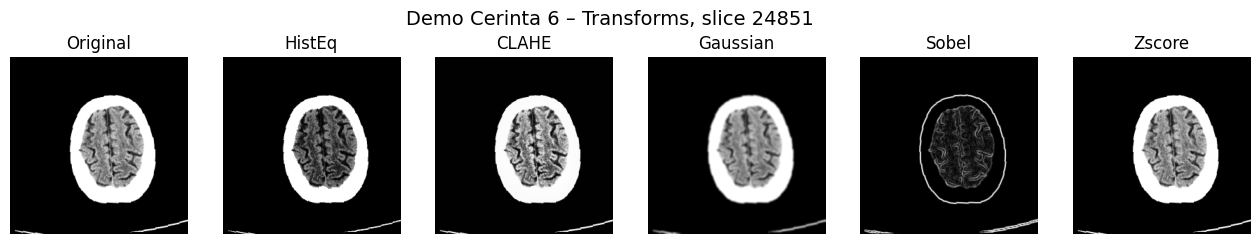

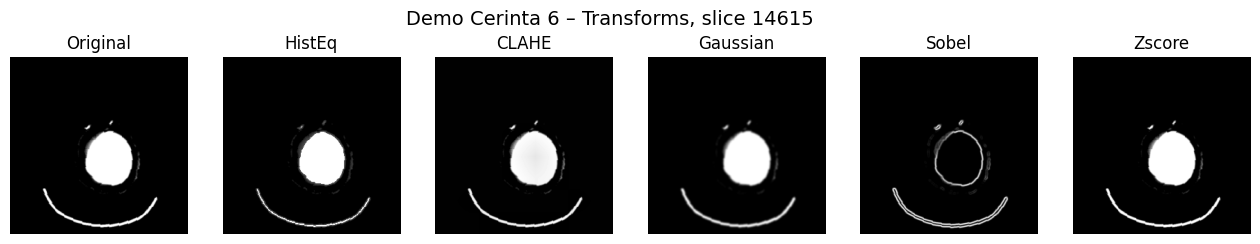

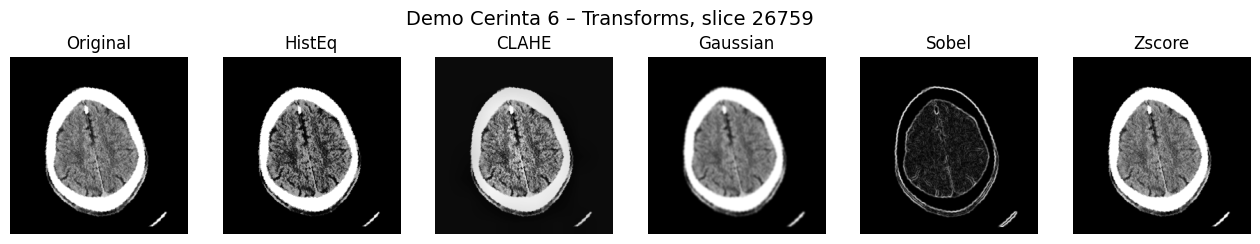

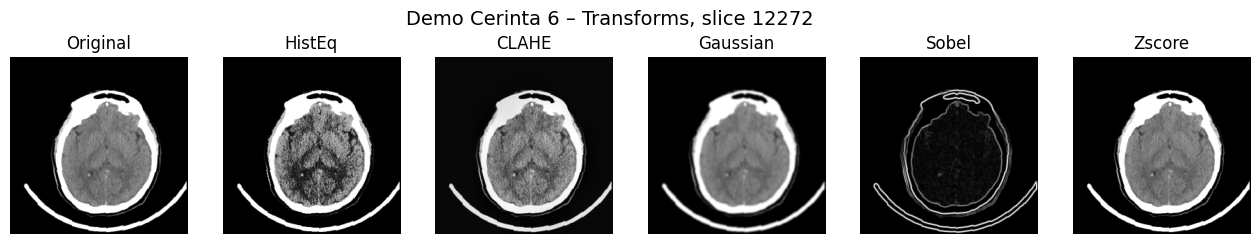

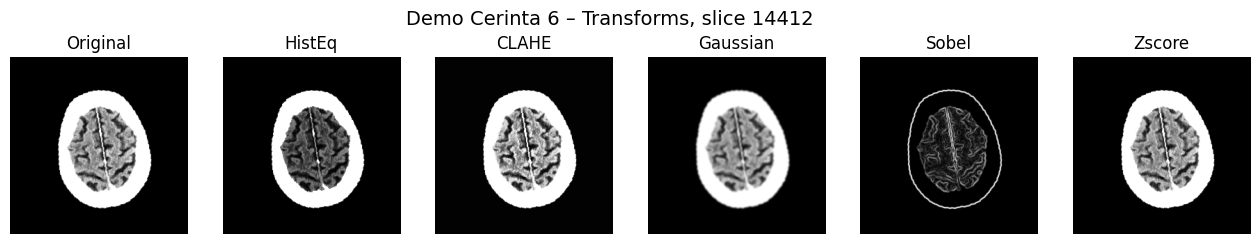

In [84]:
# =============================================================================
# Cerinta 6: Visual demo — 5 transformari aplicate pe 5 imagini random
# =============================================================================

# selectez 5 indecsi random din train_dataset
random_idxs = np. random.choice(len(train_dataset), 5, replace=False)

for idx in random_idxs:
    # extrag imaginea dupa transformarile de train (resize + normalize)
    img, _ = train_dataset[idx]
    
    # undo normalize (din [-1,1] inapoi la [0,1]) pentru afisare corecta
    img_disp = img * 0.5 + 0.5
    img_np = img_disp. squeeze().cpu().numpy()
    
    # convertesc la PIL uint8 [0,255] pentru a aplica transformarile custom
    pil256 = Image.fromarray((img_np * 255).astype("uint8"))
    
    # aplic toate transformarile si salvez in lista
    imgs = [
        ("Original", pil256),
        ("HistEq", HistogramEqTransform()(pil256)),
        ("CLAHE", CLAHETransform()(pil256)),
        ("Gaussian", GaussianBlurTransform()(pil256)),
        ("Sobel", SobelEdgeTransform()(pil256)),
        ("Zscore", ZscoreNormalizeTransform()(pil256)),
    ]
    
    # afisez toate transformarile side-by-side
    plt.figure(figsize=(16, 2.8))
    for i, (name, im) in enumerate(imgs):
        plt. subplot(1, 6, i+1)
        plt.imshow(np.array(im), cmap="gray")
        plt.title(name)
        plt.axis('off')
    plt.suptitle(f"Demo Cerinta 6 – Transforms, slice {idx}", fontsize=14)
    plt.show()

In [85]:
# verific echilibrul intre imagini sanatoase (any=0) si imagini cu hemoragie (any=1)
print("Numar imagini sanatoase (any=0):", (train_df['any'] == 0). sum())
print("Numar imagini cu cel putin o hemoragie (any=1):", (train_df['any'] == 1).sum())

Numar imagini sanatoase (any=0): 20687
Numar imagini cu cel putin o hemoragie (any=1): 11595


In [86]:
# creez un WeightedRandomSampler pentru a supraesantiona imaginile cu epidural (clasa rara)
w_epidural = 4
sample_weights = np. where(train_df['epidural'] == 1, w_epidural, 1.0)  # weight=6 pentru epidural, 1 pentru restul
sampler = WeightedRandomSampler(
    torch.DoubleTensor(sample_weights),  # vectorul de weights
    len(sample_weights),  # numarul de sample-uri per epoca (acelasi cu len(train_df))
    replacement=True  # permite resample (aceeasi imagine poate aparea de mai multe ori intr-o epoca)
)

In [87]:
# creez DataLoader pentru train cu WeightedRandomSampler (supraesantionare epidural)
train_loader = DataLoader(
    train_dataset,
    batch_size=32,           # numarul de imagini per batch
    sampler=sampler,         # folosesc samplerul custom (nu shuffle=True!)
    # shuffle = True,
    num_workers=4,           # procese paralele pentru incarcare date
    pin_memory=True          # optimizare pentru transfer GPU (mai rapid)
)

# DataLoader pentru validation (fara sampler, doar shuffle=False pentru consistenta)
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,           # nu amestec validation (vreau aceleasi metrici la fiecare epoca)
    num_workers=4
)

# DataLoader pentru test (identic cu validation)
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,           # nu amestec test
    num_workers=4
)

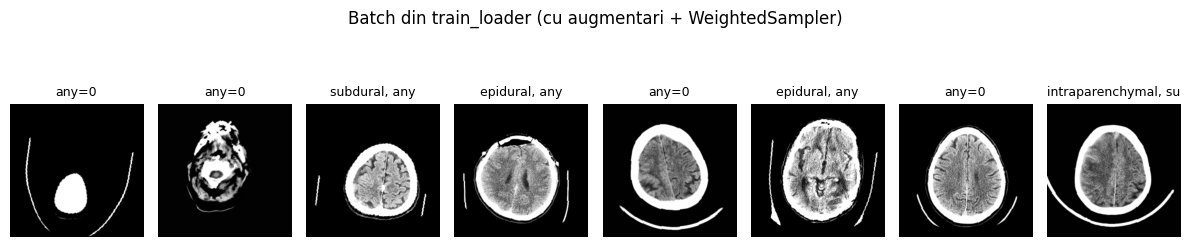

In [88]:
# verificare batch din train_loader (cu augmentari + sampler)

import matplotlib.pyplot as plt
import numpy as np

label_columns = ["epidural", "intraparenchymal", "intraventricular", "subarachnoid", "subdural", "any"]

# extrag un batch random din train_loader
images, labels = next(iter(train_loader))

# denormalizez pentru afisare (din [-1,1] inapoi la [0,1])
images_denorm = images * 0.5 + 0.5

# afisez primele 8 imagini din batch
n_show = min(8, images_denorm.shape[0])
plt.figure(figsize=(12, 3))

for i in range(n_show):
    img = images_denorm[i].cpu().numpy()  # (C, H, W)
    
    # verific daca e grayscale (1 canal) sau RGB (3 canale)
    if img.shape[0] == 1:
        img_disp = img[0]  # extrag canalul unic
        cmap = "gray"
    else:
        img_disp = np.transpose(img, (1, 2, 0))  # (C,H,W) -> (H,W,C)
        cmap = None
    
    plt.subplot(1, n_show, i+1)
    plt.imshow(img_disp, cmap=cmap)
    plt. axis('off')
    
    # afisez etichetele pozitive (clasele cu valoare 1)
    title = ", ".join([c for c, v in zip(label_columns, labels[i].cpu().numpy()) if v == 1])
    plt.title(title[:20] if title else "any=0", fontsize=9)  # limiteaza la 20 caractere

plt.suptitle("Batch din train_loader (cu augmentari + WeightedSampler)", fontsize=12)
plt.tight_layout()
plt.show()

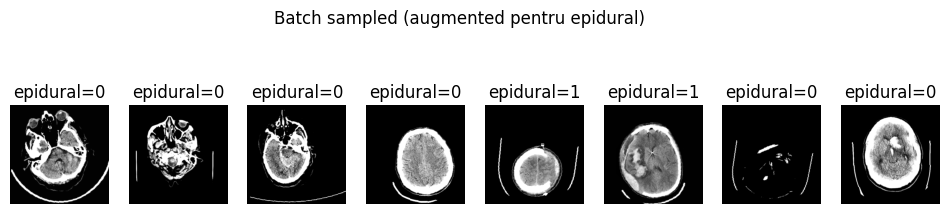

Fracție epidural în batch: 0.25


In [89]:
import matplotlib.pyplot as plt

# luam un batch
images, labels = next(iter(train_loader))  # images: [B, C, H, W], labels: [B, 6]
# convertim inapoi pentru afisare (denormalize)
images_denorm = images * 0.5 + 0.5  # undo normalize

# afisam primele 8 imagini
n_show = min(8, images_denorm.shape[0])
plt.figure(figsize=(12, 3))
for i in range(n_show):
    img = images_denorm[i].cpu().numpy()
    # shape (C,H,W) -> H,W (single channel)
    if img.shape[0] == 1:
        img_disp = img[0]
    else:
        img_disp = np.transpose(img, (1,2,0))
    plt.subplot(1, n_show, i+1)
    plt.imshow(img_disp, cmap='gray')
    plt.axis('off')
    lbl = labels[i].cpu().numpy()
    title = "epidural=" + str(int(lbl[0]))
    plt.title(title)
plt.suptitle("Batch sampled (augmented pentru epidural)")
plt.show()

# calculam fractia epidural in batch
frac_epid = labels[:,0].sum().item() / labels.shape[0]
print(f"Fracție epidural în batch: {frac_epid:.2f}")

In [90]:
epidural_present = []
for i, (_, lbls) in enumerate(train_loader):
    frac = lbls[:, 0].sum().item() / lbls.shape[0]
    epidural_present.append(frac)
    if i>=9: break
print("Fractie 'epidural' pe primele 10 batchuri (cu sampler):", [f"{x:.2f}" for x in epidural_present])

Fractie 'epidural' pe primele 10 batchuri (cu sampler): ['0.31', '0.34', '0.12', '0.06', '0.25', '0.28', '0.28', '0.22', '0.31', '0.22']


## Cerinta 7: CNN

Definesc arhitectura modelului neural pentru clasificarea multi-label a celor 6 tipuri de hemoragii.  

**Alegerea arhitecturii:**  
Initial am incercat cu un CNN simplu (scris de mana, conv layers + fully connected), dar am observat ca are dificultati la invatarea pattern-urilor complexe din imagini CT.    
Am ales sa folosesc **ResNet18** (adaptat pentru grayscale + multi-label) pentru ca:
- Rezolva problema vanishing gradient prin conexiuni reziduale (skip connections). 
- E mai profund decat un CNN simplu, dar suficient de compact pentru antrenare rapida (baseline).
- E arhitectura standard in imagistica medicala (referinta in literatura).

**Adaptari pentru task-ul meu:**
- **Input: 1 canal** (grayscale CT) in loc de 3 (RGB). 
- **Output: 2 head-uri separate** - unul pentru primele 5 clase (epidural, intraparenchymal, etc.) si unul pentru "any" (orice hemoragie). Asta permite modelului sa invete ca "any" e corelat, dar nu identic cu celelalte clase.
- **Loss: BCEWithLogitsLoss cu pos_weight** - penalizeaza mai tare erorile pe clasele rare (epidural). 

**Setup:**  
Calculez `pos_weight` din train_loader (raportul negativ/pozitiv per clasa) pentru a compensa dezechilibrul de clase.   
Modelul e instantiat pe GPU (daca e disponibil) pentru antrenare accelerata. 

In [91]:
# definirea modelului baseline

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim. lr_scheduler import ReduceLROnPlateau
import numpy as np
from tqdm import tqdm

# coloanele cu etichetele (ordinea conteaza pentru pos_weight si metrici)
label_columns = [
    "epidural",
    "intraparenchymal",
    "intraventricular",
    "subarachnoid",
    "subdural",
    "any"
]
num_classes = len(label_columns)

# --- Definitia BasicBlock (building block pentru ResNet18) ---
class BasicBlock(nn.Module):
    expansion = 1
    
    def __init__(self, in_planes, planes, stride=1, downsample=None):
        super().__init__()
        # prima convolutie (poate reduce spatial daca stride=2)
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        # a doua convolutie (pastreaza dimensiunile)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        # skip connection (daca dimensiunile se schimba)
        self. downsample = downsample
    
    def forward(self, x):
        identity = x  # salvez input-ul pentru skip connection
        
        out = self.conv1(x)
        out = self.bn1(out)
        out = self. relu(out)
        
        out = self.conv2(out)
        out = self. bn2(out)
        
        # daca e nevoie, ajustez dimensiunile skip connection-ului
        if self.downsample is not None:
            identity = self.downsample(x)
        
        out += identity  # adaug skip connection (rezidual)
        out = self. relu(out)
        return out

# --- Definitia ResNet18 adaptat pentru ICH (multi-label, grayscale) ---
class ResNet18ICH(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.in_planes = 64
        
        # stem: conv initial + maxpool (reduce spatial 256x256 -> 64x64)
        self.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)  # 1 canal grayscale! 
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        # 4 layer-uri de BasicBlock-uri (gradual creste filtre: 64->128->256->512)
        self.layer1 = self._make_layer(64, 2, stride=1)   # 2 block-uri, 64 filtre
        self.layer2 = self._make_layer(128, 2, stride=2)  # 2 block-uri, 128 filtre
        self.layer3 = self._make_layer(256, 2, stride=2)  # 2 block-uri, 256 filtre
        self.layer4 = self._make_layer(512, 2, stride=2)  # 2 block-uri, 512 filtre
        
        # global average pooling (reduce spatial la 1x1)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        
        # 2 head-uri separate: unul pt primele 5 clase, unul pt "any"
        self. head_five = nn.Linear(512, 5)   # epidural, intraparenchymal, intraventricular, subarachnoid, subdural
        self.head_any  = nn.Linear(512, 1)   # any (orice hemoragie)
    
    def _make_layer(self, planes, num_blocks, stride=1):
        """construieste un layer cu num_blocks BasicBlock-uri."""
        downsample = None
        # daca stride!=1 sau numar filtre se schimba, trebuie downsample pt skip connection
        if stride != 1 or self.in_planes != planes:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_planes, planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes)
            )
        
        layers = []
        # primul block (poate reduce spatial daca stride=2)
        layers.append(BasicBlock(self. in_planes, planes, stride, downsample))
        self. in_planes = planes
        # restul block-urilor (pastreaza dimensiunile)
        for _ in range(1, num_blocks):
            layers.append(BasicBlock(planes, planes))
        
        return nn.Sequential(*layers)
    
    def forward(self, x):
        # stem
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        
        # 4 layer-uri reziduale
        x = self. layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        
        # pooling global + flatten
        x = self.avgpool(x)
        x = torch.flatten(x, 1)  # (B, 512)
        
        # 2 head-uri separate (concatenate la final)
        out_five = self.head_five(x)  # (B, 5)
        out_any = self.head_any(x)    # (B, 1)
        out = torch.cat([out_five, out_any], dim=1)  # (B, 6)
        
        return out

# --- Setup device (GPU daca e disponibil, altfel CPU) ---
device = torch.device("cuda" if torch.cuda. is_available() else "cpu")
print("Device:", device)

# --- Instantiez modelul si il mut pe GPU ---
model = ResNet18ICH(num_classes=num_classes).to(device)

# --- Functie pentru calcul pos_weight din train_loader ---
def estimate_pos_weight(loader, num_classes):
    """calculeaza pos_weight (neg/pos) pentru fiecare clasa din loader."""
    pos_counts = np. zeros(num_classes, dtype=np.int64)
    total = 0
    
    with torch.no_grad():
        for _, labels in tqdm(loader, desc="Estimating pos_weight (train)"):
            lab = labels.cpu().numpy().astype(np.int64)
            pos_counts += lab.sum(axis=0)  # sumeaza pozitive per clasa
            total += lab. shape[0]
    
    neg_counts = total - pos_counts
    pos_counts_clamped = np. clip(pos_counts, a_min=1, a_max=None)  # evit impartire la 0
    pos_weight = neg_counts.astype(np.float32) / pos_counts_clamped.astype(np.float32)
    
    return pos_weight

Device: cuda


Implementez pipeline-ul complet pentru antrenarea modelului ResNet18 pe task-ul de clasificare multi-label:

**1. Reproductibilitate**: Setez seed-uri fixe (random, numpy, torch) pentru rezultate consistente intre rulari

**2. Verificare data leakage**: Controlez ca nu exista overlap intre imaginile din train si validation (optional, daca dataset-ul meu stocheaza ID-uri)

**3.  Calcul pos_weight**: Iterez prin train_loader pentru a estima raportul negativ/pozitiv per clasa si a compensa dezechilibrul in loss (BCEWithLogitsLoss)

**4. Setup training**: 
- **Loss**: BCEWithLogitsLoss cu pos_weight (penalizeaza mai mult erorile pe clase rare)
- **Optimizer**: Adam cu learning rate 1e-4 (standard pentru baseline)
- **Scheduler**: ReduceLROnPlateau (reduce LR daca val_loss stagnează) pentru convergenta mai buna

**5. Training loop** (20 epoci cu early stopping patience=5):
- Calculez loss pe train si validation
- Monitorizez metrici multiple: macro-accuracy (medie per-class accuracy), exact-match accuracy (toate cele 6 etichete corecte simultan), precision/recall/f1 per clasa
- Salvez 2 modele: cel cu best val_loss si cel cu best macro_f1 (ca sa compar dupa)
- Early stopping pe val_loss (daca nu se imbunatateste 5 epoci consecutive, opresc antrenarea)

**6.  Vizualizare**: Plotez evolutia loss-ului si a macro-accuracy pe train/val de-a lungul epocilor (cerinta 7 expliciata)

**7. Matrici de confuzie**: Afisez confusion matrix per clasa pe validation set pentru a identifica clasele problematice (unde modelul confunda pozitiv/negativ)

**Observatii asteptate** (dupa antrenare):  
- Epidural va avea recall scazut (clasa rara, greu de detectat chiar cu pos_weight)
- "Any" va avea performanta mai buna (clasa agregata, mai multe exemple pozitive)
- Overfitting posibil daca train_loss scade mult mai rapid decat val_loss (semn ca am nevoie de mai multe augmentari sau regularizare)

Estimating pos_weight (train): 100%|██████████| 1009/1009 [01:16<00:00, 13.12it/s]


pos_weight (per class): [2.9167678 5.5137205 8.370682  5.8772902 5.8292785 1.063275 ]
pos_counts: [ 8242  4956  3445  4694  4727 15646] total train samples: 32282


Val 1: 100%|██████████| 253/253 [00:16<00:00, 15.22it/s]


[Epoch 1] loss_train=0.8235, loss_val=0.9774
    Train macro-acc: 0.6953, Val macro-acc: 0.5264
    Train exact-match: 0.3511, Val exact-match: 0.2500
    Current LR: 1.00e-04
    - Per-class metrics (val):
       - epidural         precision: 0.108, recall: 0.969, f1: 0.194, support: 583
       - intraparenchymal precision: 0.242, recall: 0.976, f1: 0.388, support: 1191
       - intraventricular precision: 0.227, recall: 0.988, f1: 0.369, support: 968
       - subarachnoid     precision: 0.219, recall: 0.946, f1: 0.356, support: 1115
       - subdural         precision: 0.190, recall: 0.985, f1: 0.319, support: 1070
       - any              precision: 0.500, recall: 0.983, f1: 0.663, support: 2964
    [Val macro avg] precision: 0.248, recall: 0.975, f1: 0.381
    Per-class accuracy (val):
       epidural        : 0.418
       intraparenchymal: 0.546
       intraventricular: 0.594
       subarachnoid    : 0.526
       subdural        : 0.442
       any             : 0.632


Val 2: 100%|██████████| 253/253 [00:16<00:00, 15.20it/s]


...

[Epoch 16] loss_train=0.3018, loss_val=0.4865
    Train macro-acc: 0.9177, Val macro-acc: 0.8913
    Train exact-match: 0.6868, Val exact-match: 0.6267
    Current LR: 2.50e-05
    - Per-class metrics (val):
       - epidural         precision: 0.761, recall: 0.487, f1: 0.594, support: 583
       - intraparenchymal precision: 0.569, recall: 0.885, f1: 0.693, support: 1191
       - intraventricular precision: 0.674, recall: 0.899, f1: 0.771, support: 968
       - subarachnoid     precision: 0.498, recall: 0.734, f1: 0.593, support: 1115
       - subdural         precision: 0.418, recall: 0.809, f1: 0.551, support: 1070
       - any              precision: 0.918, recall: 0.768, f1: 0.836, support: 2964
    [Val macro avg] precision: 0.640, recall: 0.764, f1: 0.673
    Per-class accuracy (val):
       epidural        : 0.952
       intraparenchymal: 0.884
       intraventricular: 0.936
       subarachnoid    : 0.861
       subdural        : 0.825
       any             : 0.889


Val 17: 100%|██████████| 253/253 [00:16<00:00, 15.40it/s]


[Epoch 17] loss_train=0.2736, loss_val=0.4857
    Train macro-acc: 0.9259, Val macro-acc: 0.8919
    Train exact-match: 0.7102, Val exact-match: 0.6248
    Current LR: 2.50e-05
    - Per-class metrics (val):
       - epidural         precision: 0.526, recall: 0.852, f1: 0.651, support: 583
       - intraparenchymal precision: 0.587, recall: 0.871, f1: 0.701, support: 1191
       - intraventricular precision: 0.671, recall: 0.899, f1: 0.769, support: 968
       - subarachnoid     precision: 0.549, recall: 0.692, f1: 0.612, support: 1115
       - subdural         precision: 0.402, recall: 0.794, f1: 0.534, support: 1070
       - any              precision: 0.851, recall: 0.871, f1: 0.861, support: 2964
    [Val macro avg] precision: 0.598, recall: 0.830, f1: 0.688
    Per-class accuracy (val):
       epidural        : 0.934
       intraparenchymal: 0.890
       intraventricular: 0.935
       subarachnoid    : 0.879
       subdural        : 0.816
       any             : 0.897


Val 18: 100%|██████████| 253/253 [00:16<00:00, 15.47it/s]


[Epoch 18] loss_train=0.2546, loss_val=0.4757
    Train macro-acc: 0.9316, Val macro-acc: 0.8958
    Train exact-match: 0.7286, Val exact-match: 0.6370
    Current LR: 2.50e-05
    - Per-class metrics (val):
       - epidural         precision: 0.550, recall: 0.846, f1: 0.667, support: 583
       - intraparenchymal precision: 0.650, recall: 0.815, f1: 0.724, support: 1191
       - intraventricular precision: 0.641, recall: 0.918, f1: 0.755, support: 968
       - subarachnoid     precision: 0.478, recall: 0.769, f1: 0.589, support: 1115
       - subdural         precision: 0.459, recall: 0.714, f1: 0.559, support: 1070
       - any              precision: 0.847, recall: 0.877, f1: 0.862, support: 2964
    [Val macro avg] precision: 0.604, recall: 0.823, f1: 0.693
    Per-class accuracy (val):
       epidural        : 0.939
       intraparenchymal: 0.908
       intraventricular: 0.929
       subarachnoid    : 0.852
       subdural        : 0.850
       any             : 0.897
Early stopp

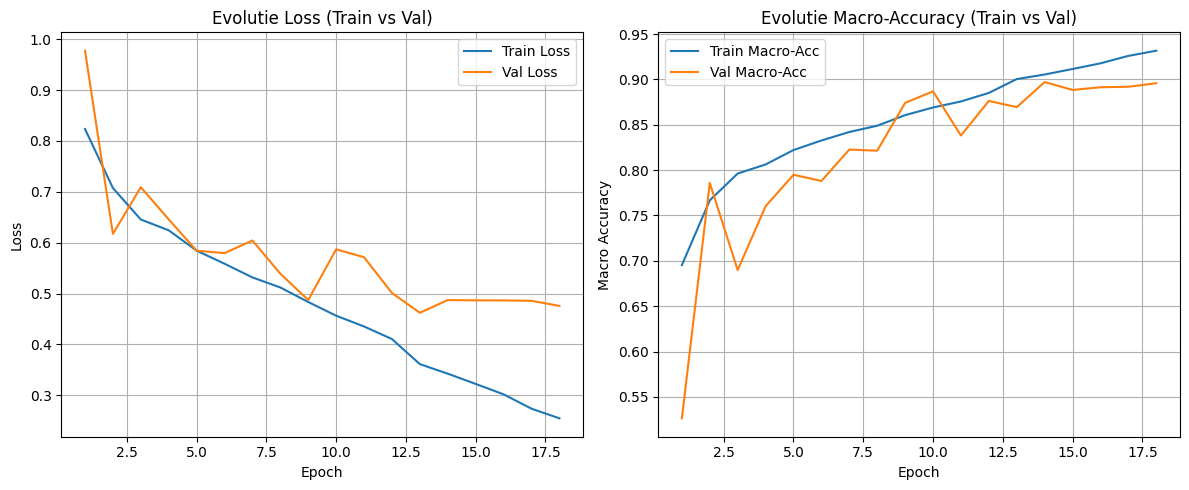

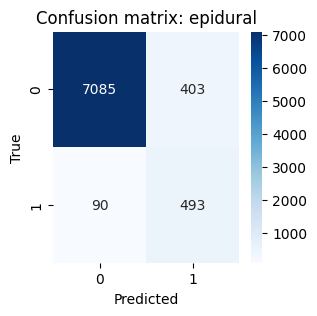

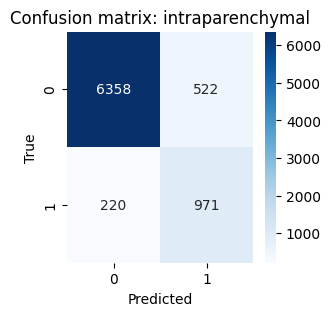

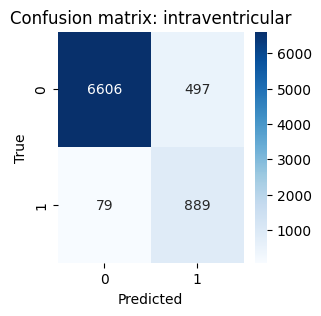

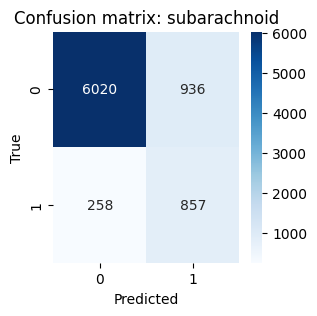

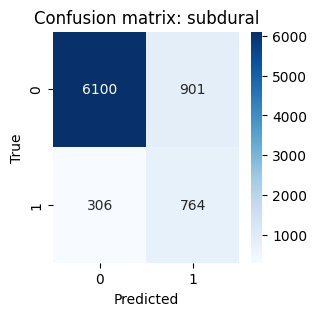

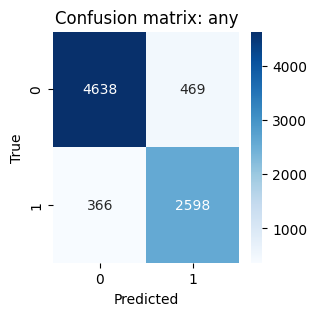


TRAINING FINISHED
Best val loss: 0.462113
Best macro F1 (val): 0.692527
Models saved: best_model_by_val_loss.pt, best_model_by_macro_f1.pt


In [92]:
# pipeline complet de antrenare si evaluare baseline

import torch
import torch.nn as nn
import torch.optim as optim
from torch. optim. lr_scheduler import ReduceLROnPlateau
import numpy as np
from tqdm import tqdm
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# reproductibilitate (seed fix pentru rezultate consistente)
def set_seed(seed=42):
    import random, os
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    try:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except:
        pass

set_seed(42)

# verificare data leakage (optional, daca dataset-ul are atribut image_ids)
try:
    train_ids = set(getattr(train_loader.dataset, "image_ids", []))
    val_ids = set(getattr(val_loader. dataset, "image_ids", []))
    if len(train_ids) and len(val_ids):
        inter = train_ids.intersection(val_ids)
        assert len(inter) == 0, f"DATA LEAKAGE: {len(inter)} overlapping sample ids between train & val"
except AssertionError as e:
    print("Assertion error (data leakage):", e)
except Exception:
    # daca dataset-ul nu are image_ids, continui
    pass

# calcul pos_weight automat din train set (pentru BCEWithLogitsLoss)
def estimate_pos_weight(loader, num_classes):
    """itereaza prin loader si numara pozitive/negative per clasa."""
    pos_counts = np. zeros(num_classes, dtype=np.int64)
    total = 0
    with torch.no_grad():
        for _, labels in tqdm(loader, desc="Estimating pos_weight (train)"):
            lab = labels.cpu().numpy(). astype(np.int64)
            pos_counts += lab. sum(axis=0)  # sumeaza pozitive per clasa
            total += lab. shape[0]
    
    neg_counts = total - pos_counts
    pos_counts_clamped = np.clip(pos_counts, a_min=1, a_max=None)  # evit impartire la 0
    pos_weight = neg_counts. astype(np.float32) / pos_counts_clamped. astype(np.float32)
    return pos_weight, pos_counts, total

num_classes = len(label_columns)
pos_weight_np, pos_counts, total_samples_train = estimate_pos_weight(train_loader, num_classes)
print("pos_weight (per class):", pos_weight_np)
print("pos_counts:", pos_counts, "total train samples:", total_samples_train)

pos_weight = torch.tensor(pos_weight_np, dtype=torch.float32). to(device)

# criterion, optimizer, scheduler
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)  # loss cu penalizare pe clase rare
optimizer = optim.Adam(model.parameters(), lr=1e-4)  # optimizer standard pentru baseline
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)  # reduce LR daca val_loss stagnează

# training loop cu metrici, salvare best model, early stopping
EPOCHS = 20
PATIENCE_ES = 5  # early stopping daca val_loss nu se imbunatateste 5 epoci consecutive
best_val_loss = float("inf")
best_weights_by_loss = None
best_macro_f1 = -1.0
best_weights_by_macro_f1 = None
epochs_no_improve = 0

# liste pentru plotare evolutie metrici
train_losses, val_losses = [], []
train_macro_accs, val_macro_accs = [], []
train_exact_match_accs, val_exact_match_accs = [], []

for epoch in range(EPOCHS):
    # ===== TRAIN =====
    model.train()
    train_loss = 0.0
    all_train_logits = []
    all_train_labels = []
    
    with torch.set_grad_enabled(True):
        for images, labels in tqdm(train_loader, desc=f"Train {epoch+1}"):
            images = images.to(device)
            labels = labels.to(device).float()

            optimizer.zero_grad()
            outputs = model(images)  # (B, 6)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.shape[0]  # acumuleaza loss total

            # colectez logits si labels pentru calcul metrici la final de epoca
            all_train_logits.append(outputs.detach().cpu(). numpy())
            all_train_labels.append(labels.detach().cpu().numpy())

    # medie loss per sample
    epoch_train_loss = train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # stack predictions/labels pentru calcul accuracies
    all_train_logits = np.vstack(all_train_logits)
    all_train_labels = np.vstack(all_train_labels)
    train_probs = 1 / (1 + np.exp(-all_train_logits))  # sigmoid
    train_preds = (train_probs > 0.5).astype(int)  # threshold 0.5

    # per-class accuracy (proportie corecte per clasa)
    per_class_acc_train = (train_preds == all_train_labels).sum(axis=0) / all_train_labels. shape[0]
    train_macro_acc = per_class_acc_train.mean()
    train_macro_accs.append(train_macro_acc)

    # exact-match accuracy (toate cele 6 etichete corecte simultan)
    train_exact_match = (train_preds == all_train_labels).all(axis=1). mean()
    train_exact_match_accs.append(train_exact_match)

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0.0
    all_val_logits = []
    all_val_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Val {epoch+1}"):
            images = images.to(device)
            labels = labels.to(device).float()

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.shape[0]

            all_val_logits.append(outputs.cpu().numpy())
            all_val_labels.append(labels.cpu().numpy())

    epoch_val_loss = val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    all_val_logits = np. vstack(all_val_logits)
    all_val_labels = np.vstack(all_val_labels)
    val_probs = 1 / (1 + np.exp(-all_val_logits))
    val_preds = (val_probs > 0.5).astype(int)

    # per-class accuracy validation
    per_class_acc_val = (val_preds == all_val_labels).sum(axis=0) / all_val_labels.shape[0]
    val_macro_acc = per_class_acc_val.mean()
    val_macro_accs.append(val_macro_acc)

    # exact-match accuracy val
    val_exact_match = (val_preds == all_val_labels).all(axis=1).mean()
    val_exact_match_accs.append(val_exact_match)

    # classification report per-class (precision/recall/f1)
    val_classif = classification_report(
        all_val_labels, val_preds,
        target_names=label_columns,
        digits=3,
        output_dict=True,
        zero_division=0
    )

    # macro F1 (medie f1 peste toate clasele)
    macro_f1 = val_classif['macro avg']['f1-score']
    
    # update scheduler (reduce LR daca val_loss nu scade)
    scheduler.step(epoch_val_loss)

    # salvez best model by val loss
    if epoch_val_loss < best_val_loss - 1e-12:
        best_val_loss = epoch_val_loss
        best_weights_by_loss = model.state_dict().copy()
        torch.save(best_weights_by_loss, "best_model_by_val_loss.pt")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    # salvez best model by macro F1
    if macro_f1 > best_macro_f1 + 1e-12:
        best_macro_f1 = macro_f1
        best_weights_by_macro_f1 = model.state_dict().copy()
        torch.save(best_weights_by_macro_f1, "best_model_by_macro_f1.pt")

    # logging: afisez sumar per epoca
    print(f"[Epoch {epoch+1}] loss_train={epoch_train_loss:.4f}, loss_val={epoch_val_loss:.4f}")
    print(f"    Train macro-acc: {train_macro_acc:.4f}, Val macro-acc: {val_macro_acc:.4f}")
    print(f"    Train exact-match: {train_exact_match:.4f}, Val exact-match: {val_exact_match:.4f}")
    print(f"    Current LR: {optimizer.param_groups[0]['lr']:.2e}")
    print("    - Per-class metrics (val):")
    for cls in label_columns:
        pr = val_classif[cls]['precision']
        rc = val_classif[cls]['recall']
        f1 = val_classif[cls]['f1-score']
        sup = int(val_classif[cls]['support'])
        print(f"       - {cls:16} precision: {pr:.3f}, recall: {rc:.3f}, f1: {f1:.3f}, support: {sup}")
    print(f"    [Val macro avg] precision: {val_classif['macro avg']['precision']:.3f}, recall: {val_classif['macro avg']['recall']:.3f}, f1: {val_classif['macro avg']['f1-score']:.3f}")

    # afisez per-class accuracy (util pentru clase rare)
    print("    Per-class accuracy (val):")
    for idx, name in enumerate(label_columns):
        print(f"       {name:16}: {per_class_acc_val[idx]:.3f}")

    # early stopping check
    if epochs_no_improve >= PATIENCE_ES:
        print(f"Early stopping triggered after {epoch+1} epochs (no improvement in val_loss for {PATIENCE_ES} epochs).")
        break

# dupa training: incarc best model (prefer macro_f1, daca nu exista atunci val_loss)
if best_weights_by_macro_f1 is not None:
    model.load_state_dict(best_weights_by_macro_f1)
    print("Loaded best model by macro F1 for final evaluation.")
elif best_weights_by_loss is not None:
    model.load_state_dict(best_weights_by_loss)
    print("Loaded best model by val loss for final evaluation.")

# plots: evolutie loss si accuracy per epoca
epochs_ran = np.arange(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

# grafic loss
plt.subplot(1, 2, 1)
plt.plot(epochs_ran, train_losses, label="Train Loss", marker='')
plt.plot(epochs_ran, val_losses, label="Val Loss", marker='')
plt. xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Evolutie Loss (Train vs Val)")
plt. legend()
plt.grid(True)

# grafic macro-accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_ran, train_macro_accs, label="Train Macro-Acc", marker='')
plt.plot(epochs_ran, val_macro_accs, label="Val Macro-Acc", marker='')
plt.xlabel("Epoch")
plt.ylabel("Macro Accuracy")
plt.title("Evolutie Macro-Accuracy (Train vs Val)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# matrici de confuzie per clasa pe validation set
for i, name in enumerate(label_columns):
    cm = confusion_matrix(all_val_labels[:, i], val_preds[:, i])
    plt.figure(figsize=(3, 3))
    sns. heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion matrix: {name}")
    plt. xlabel("Predicted")
    plt. ylabel("True")
    plt.show()

# sumar final pentru raport
print("\n" + "="*60)
print("TRAINING FINISHED")
print("="*60)
print(f"Best val loss: {best_val_loss:.6f}")
print(f"Best macro F1 (val): {best_macro_f1:.6f}")
print("Models saved: best_model_by_val_loss.pt, best_model_by_macro_f1.pt")
print("="*60)

In [97]:
# threshold tuning per clasa pe validation set

from sklearn.metrics import f1_score

# incarc best model (by val_loss) pentru threshold tuning
model.load_state_dict(torch.load("best_model_by_val_loss.pt"))
model.eval()

# colectez toate logits si labels din validation set
all_val_logits, all_val_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        all_val_logits.append(outputs.cpu().numpy())
        all_val_labels.append(labels.cpu().numpy())

all_val_logits = np. vstack(all_val_logits)
all_val_labels = np.vstack(all_val_labels)
val_probs = 1 / (1 + np.exp(-all_val_logits))  # sigmoid(logits) -> probabilitati in [0,1]

# cautare prag optimal per clasa (grid search pe validation set)
optimal_thresholds = []
print("Optimizing threshold per clasa (validation set):")

for c in range(val_probs.shape[1]):
    best_thr, best_f1 = 0.5, 0  # default: threshold=0.5, f1=0
    
    # testez praguri intre 0.1 si 0.9 (step 0.05)
    for thr in np.arange(0.1, 0.91, 0.05):
        y_pred = (val_probs[:, c] >= thr).astype(int)  # predictii cu pragul thr
        f1 = f1_score(all_val_labels[:, c], y_pred, zero_division=0)  # calculeaza F1
        
        # daca f1 mai bun, updatez best
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr
    
    optimal_thresholds. append(best_thr)
    print(f"{label_columns[c]:<16}: threshold={best_thr:.2f}, val_f1={best_f1:.3f}")

Optimizing threshold per clasa (validation set):
epidural        : threshold=0.70, val_f1=0.647
intraparenchymal: threshold=0.75, val_f1=0.738
intraventricular: threshold=0.85, val_f1=0.809
subarachnoid    : threshold=0.90, val_f1=0.601
subdural        : threshold=0.65, val_f1=0.572
any             : threshold=0.55, val_f1=0.860


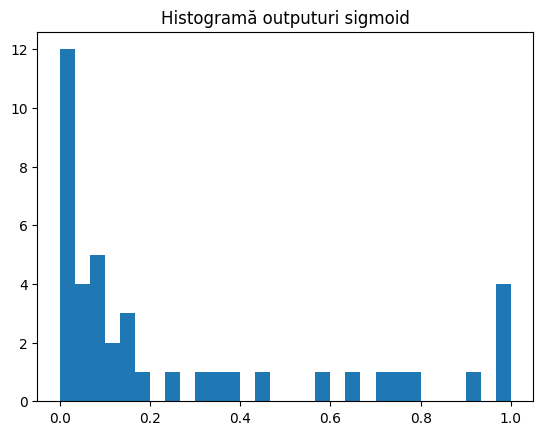

In [98]:
import matplotlib.pyplot as plt
plt.hist(torch.sigmoid(outputs).cpu().flatten().numpy(), bins=30)
plt.title("Histogramă outputuri sigmoid")
plt.show()

Test: 100%|██████████| 279/279 [00:18<00:00, 15.16it/s]



[TEST ACCURACY per class]:
  epidural            : 0.938
  intraparenchymal    : 0.794
  intraventricular    : 0.873
  subarachnoid        : 0.724
  subdural            : 0.744
  any                 : 0.862

[TEST METRICS - Classification Report]:
                  precision    recall  f1-score   support

        epidural      0.134     0.634     0.221       123
intraparenchymal      0.731     0.743     0.737      3463
intraventricular      0.790     0.849     0.819      3011
    subarachnoid      0.620     0.659     0.638      3292
        subdural      0.650     0.610     0.629      3170
             any      0.988     0.857     0.918      8034

       micro avg      0.779     0.768     0.774     21093
       macro avg      0.652     0.725     0.660     21093
    weighted avg      0.804     0.768     0.783     21093
     samples avg      0.642     0.679     0.641     21093


[Test] Macro accuracy (all labels correct): 0.341

[Confusion Matrices per Class]:


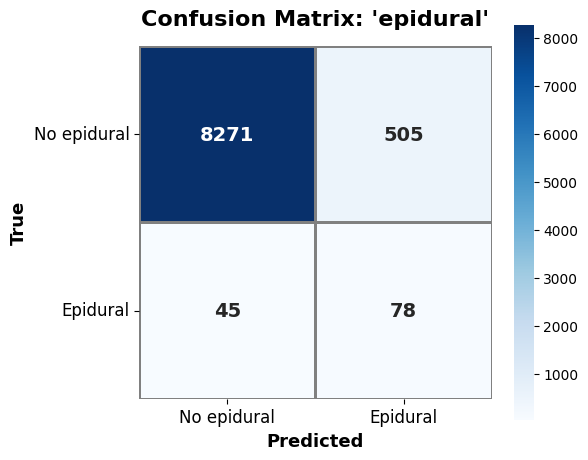


--- Metrics for 'epidural' ---
  TN (True Negative):   8271  |  FP (False Positive):   505
  FN (False Negative):    45  |  TP (True Positive):     78
  Precision: 0.134  |  Recall: 0.634  |  F1-score: 0.221
------------------------------------------------------------


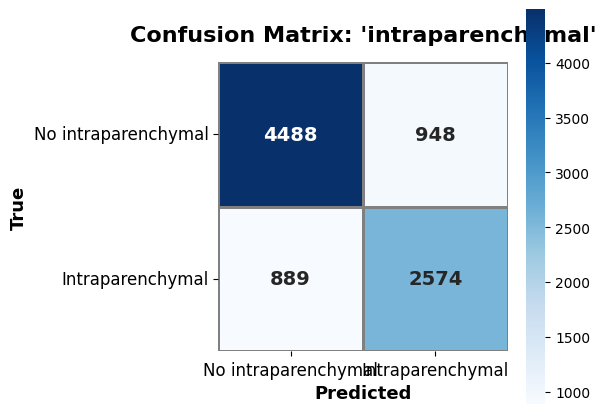


--- Metrics for 'intraparenchymal' ---
  TN (True Negative):   4488  |  FP (False Positive):   948
  FN (False Negative):   889  |  TP (True Positive):   2574
  Precision: 0.731  |  Recall: 0.743  |  F1-score: 0.737
------------------------------------------------------------


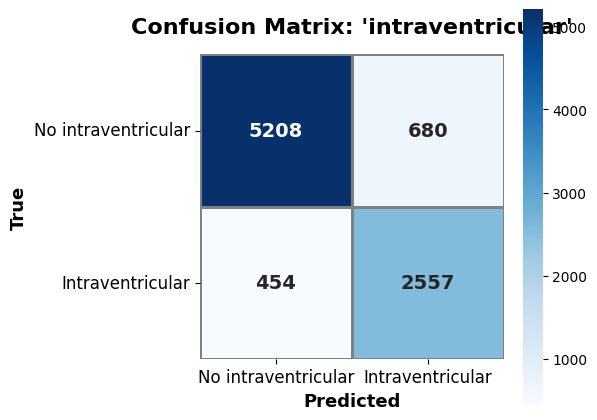


--- Metrics for 'intraventricular' ---
  TN (True Negative):   5208  |  FP (False Positive):   680
  FN (False Negative):   454  |  TP (True Positive):   2557
  Precision: 0.790  |  Recall: 0.849  |  F1-score: 0.819
------------------------------------------------------------


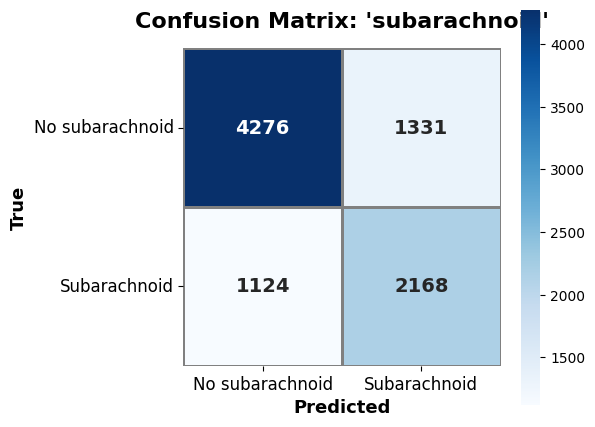


--- Metrics for 'subarachnoid' ---
  TN (True Negative):   4276  |  FP (False Positive):  1331
  FN (False Negative):  1124  |  TP (True Positive):   2168
  Precision: 0.620  |  Recall: 0.659  |  F1-score: 0.638
------------------------------------------------------------


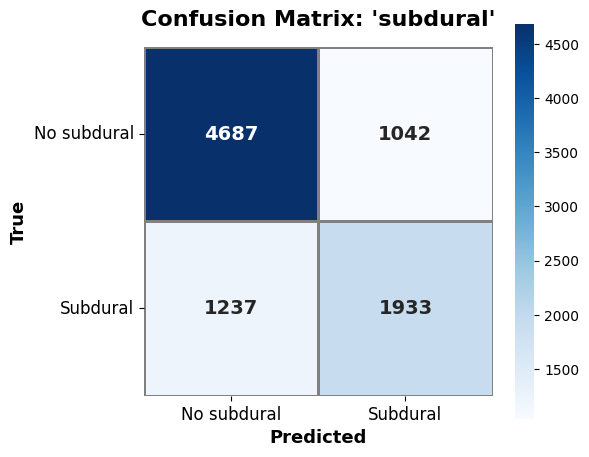


--- Metrics for 'subdural' ---
  TN (True Negative):   4687  |  FP (False Positive):  1042
  FN (False Negative):  1237  |  TP (True Positive):   1933
  Precision: 0.650  |  Recall: 0.610  |  F1-score: 0.629
------------------------------------------------------------


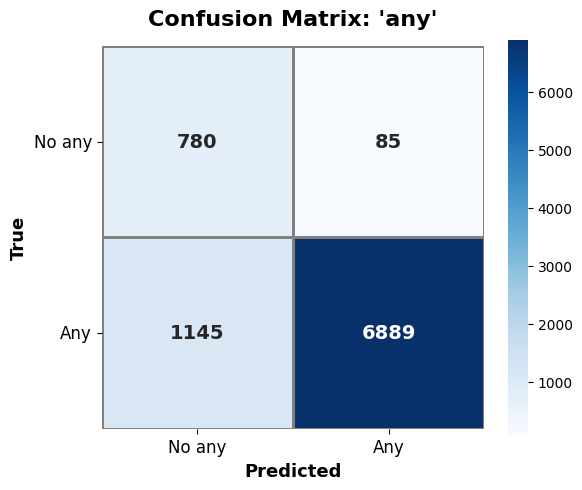


--- Metrics for 'any' ---
  TN (True Negative):    780  |  FP (False Positive):    85
  FN (False Negative):  1145  |  TP (True Positive):   6889
  Precision: 0.988  |  Recall: 0.857  |  F1-score: 0.918
------------------------------------------------------------


In [ ]:
# evaluare model pe test_loader cu best_weights, calibrare cu optimal_thresholds

model.load_state_dict(torch.load("best_model_by_val_loss.pt"))
model.eval()

# --- Colectare predictii si etichete pe test ---
all_test_logits, all_test_labels = [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Test"):
        images = images.to(device)
        outputs = model(images)
        all_test_logits.append(outputs.cpu().numpy())
        all_test_labels.append(labels.cpu().numpy())

all_test_logits = np.vstack(all_test_logits)
all_test_labels = np.vstack(all_test_labels)
test_probs = 1 / (1 + np.exp(-all_test_logits))  # sigmoid

# --- Aplica threshold-urile optime (calibrate pe validation) ---
test_preds_tuned = np.zeros_like(test_probs)
for c, thr in enumerate(optimal_thresholds):
    test_preds_tuned[:, c] = (test_probs[:, c] >= thr).astype(int)

# --- Afiseaza acuratetea per clasa ---
per_class_acc = (test_preds_tuned == all_test_labels).sum(axis=0) / all_test_labels.shape[0]
print("\n" + "="*60)
print("[TEST ACCURACY per class]:")
print("="*60)
for idx, label in enumerate(label_columns):
    print(f"  {label:20s}: {per_class_acc[idx]:.3f}")

# --- Classification report complet ---
print("\n" + "="*60)
print("[TEST METRICS - Classification Report]:")
print("="*60)
print(classification_report(
    all_test_labels, 
    test_preds_tuned, 
    target_names=label_columns, 
    digits=3, 
    zero_division=0
))

# --- Macro accuracy (multi-label) ---
macro_acc = accuracy_score(all_test_labels, test_preds_tuned)
print(f"\n[Test] Macro accuracy (all labels correct): {macro_acc:.3f}\n")

# --- Matrici de confuzie pentru fiecare clasa (ploturi clare) ---
print("="*60)
print("[Confusion Matrices per Class]:")
print("="*60)

for idx, name in enumerate(label_columns):
    y_true = all_test_labels[:, idx]
    y_pred = test_preds_tuned[:, idx]
    cm = confusion_matrix(y_true, y_pred)
    
    # Plotează confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True, 
                square=True, linewidths=1, linecolor='gray',
                annot_kws={"size": 14, "weight": "bold"})
    
    plt.title(f"Confusion Matrix: '{name}'", fontsize=16, weight='bold', pad=15)
    plt.xlabel("Predicted", fontsize=13, weight='bold')
    plt. ylabel("True", fontsize=13, weight='bold')
    
    # Etichete clare pe axe
    plt.xticks([0.5, 1.5], [f"No {name}", name.capitalize()], fontsize=12)
    plt.yticks([0.5, 1.5], [f"No {name}", name.capitalize()], fontsize=12, rotation=0)
    
    plt.tight_layout()
    plt.show()
    
    # Afiseaza metrici din matrice pentru fiecare clasa
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"\n--- Metrics for '{name}' ---")
    print(f"  TN (True Negative):  {tn:5d}  |  FP (False Positive): {fp:5d}")
    print(f"  FN (False Negative): {fn:5d}  |  TP (True Positive):  {tp:5d}")
    print(f"  Precision: {precision:.3f}  |  Recall: {recall:.3f}  |  F1-score: {f1:.3f}")
    print("-" * 60)

In [100]:
print(len(optimal_thresholds), optimal_thresholds)
print(test_probs.shape)

6 [0.7000000000000002, 0.7500000000000002, 0.8500000000000002, 0.9000000000000002, 0.6500000000000001, 0.5500000000000002]
(8899, 6)
